<a href="https://colab.research.google.com/github/wangechi01-a/AI-Coding-Assistant/blob/main/Hardwin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Can you predict the financial well-being of small businesses?

This challenge introduces a data-driven Financial Health Index (FHI) for SMEs - a composite measure that classifies businesses into Low, Medium, or High financial health across four key dimensions: savings and assets, debt and repayment ability, resilience to shocks, and access to credit and financial services. Derived from survey and business data, the FHI offers a more complete picture of financial stability and inclusion.

In [68]:
!pip install catboost
!pip install lightgbm
!pip install xgboost
!pip install optuna



* Import Dependencies

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import unicodedata
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline
from scipy.optimize import minimize # Added this import

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import warnings
import itertools
warnings.filterwarnings('ignore')

In [70]:
def canonize_text(df, columns):
    """
    NFKC normalization for categorical columns.
    Consolidates scattered variants like "Don't know", "Dont know", etc.
    """
    df = df.copy()
    for col in columns:
        if col in df.columns and df[col].dtype == 'object':
            # Apply NFKC normalization
            df[col] = df[col].astype(str).apply(
                lambda x: unicodedata.normalize('NFKC', x).strip().lower()
            )
            # Consolidate common variants
            df[col] = df[col].replace({
                "dont know": "don't know",
                "do not know": "don't know",
                "don t know": "don't know",
                "don’t know (do not show)": "don't know", # Added this line
                "missing": "missing",
                "nan": "missing",
                "none": "missing",
                "no": "no",
                "yes": "yes",
                "have now": "have now",
                "never had": "never had",
                "do not have": "do not have",
                "dont have": "do not have"
            })
    return df


def optimize_thresholds_nelder_mead(y_true, y_proba, country_name):
    """
    Use Nelder-Mead optimization to find class multipliers that maximize F1-macro.
    Returns optimal multipliers for each class.
    """
    def neg_f1(multipliers):
        # Apply multipliers to probabilities
        adjusted_proba = y_proba * np.array(multipliers)
        preds = np.argmax(adjusted_proba, axis=1)
        return -f1_score(y_true, preds, average='macro')

    # Initial guess: equal multipliers
    x0 = np.array([1.0, 1.0, 1.0])

    # Bounds: multipliers between 0.5 and 5.0
    bounds = [(0.5, 5.0), (0.5, 5.0), (0.5, 5.0)]

    # Optimize
    result = minimize(
        neg_f1,
        x0,
        method='Nelder-Mead',
        bounds=bounds,
        options={'maxiter': 1000, 'xatol': 1e-8, 'disp': False}
    )

    optimal_multipliers = result.x
    best_f1 = -result.fun

    print(f"\n{country_name} Threshold Optimization:")
    print(f"  Optimal multipliers: {optimal_multipliers.round(3)}")
    print(f"  Optimized F1: {best_f1:.4f}")

    # Compare to default
    default_f1 = f1_score(y_true, np.argmax(y_proba, axis=1), average='macro')
    print(f"  Default F1: {default_f1:.4f} (gain: +{best_f1 - default_f1:.4f})")

    return optimal_multipliers, best_f1

def apply_threshold_multipliers(proba, multipliers):
    """Apply optimized multipliers to probabilities."""
    adjusted = proba * np.array(multipliers)
    return np.argmax(adjusted, axis=1)


def ordinal_ensemble_predict(predictions_list):
    """
    Average predictions from multiple seeds treating target as ordinal.
    predictions_list: list of arrays with values 0, 1, 2 (Low, Medium, High)
    """
    # Convert to numpy array
    all_preds = np.array(predictions_list)  # Shape: (n_seeds, n_samples)

    # Calculate mean (continuous value between 0 and 2)
    mean_pred = np.mean(all_preds, axis=0)

    # Round to nearest integer and clip to valid range
    final_pred = np.round(mean_pred).astype(int).clip(0, 2)

    return final_pred

* Load the data

In [71]:
train = pd.read_csv("/content/drive/MyDrive/dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n/Train.csv")
test = pd.read_csv("/content/drive/MyDrive/dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n/Test.csv")
var_df = pd.read_csv("/content/drive/MyDrive/dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n/VariableDefinitions.csv")
sample_sub = pd.read_csv("/content/drive/MyDrive/dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n/SampleSubmission.csv")

* Explore the data

In [72]:
train.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


In [73]:
test.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


In [74]:
display(var_df)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


In [75]:
train.columns

Index(['ID', 'country', 'owner_age', 'attitude_stable_business_environment',
       'attitude_worried_shutdown', 'compliance_income_tax',
       'perception_insurance_doesnt_cover_losses',
       'perception_cannot_afford_insurance', 'personal_income',
       'business_expenses', 'business_turnover', 'business_age_years',
       'motor_vehicle_insurance', 'has_mobile_money',
       'current_problem_cash_flow', 'has_cellphone', 'owner_sex',
       'offers_credit_to_customers', 'attitude_satisfied_with_achievement',
       'has_credit_card', 'keeps_financial_records',
       'perception_insurance_companies_dont_insure_businesses_like_yours',
       'perception_insurance_important', 'has_insurance',
       'covid_essential_service', 'attitude_more_successful_next_year',
       'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account',
       'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock',
       'business_age_months', 'medical_insurance', 'funeral_insura

In [76]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                9618 non-null   object 
 1   country                                                           9618 non-null   object 
 2   owner_age                                                         9618 non-null   float64
 3   attitude_stable_business_environment                              9616 non-null   object 
 4   attitude_worried_shutdown                                         9616 non-null   object 
 5   compliance_income_tax                                             9614 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          9613 non-null   object 
 7   perception_cannot_afford_insuranc

In [77]:
train.isnull().sum()

,0
ID,0
country,0
owner_age,0
attitude_stable_business_environment,2
attitude_worried_shutdown,2
compliance_income_tax,4
perception_insurance_doesnt_cover_losses,5
perception_cannot_afford_insurance,5
personal_income,109
business_expenses,229


In [78]:
train.duplicated().sum()

np.int64(0)

In [79]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2405 entries, 0 to 2404
Data columns (total 38 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                2405 non-null   object 
 1   country                                                           2405 non-null   object 
 2   owner_age                                                         2404 non-null   float64
 3   attitude_stable_business_environment                              2405 non-null   object 
 4   attitude_worried_shutdown                                         2405 non-null   object 
 5   compliance_income_tax                                             2405 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          2403 non-null   object 
 7   perception_cannot_afford_insuranc

In [80]:
test.columns

Index(['ID', 'country', 'owner_age', 'attitude_stable_business_environment',
       'attitude_worried_shutdown', 'compliance_income_tax',
       'perception_insurance_doesnt_cover_losses',
       'perception_cannot_afford_insurance', 'personal_income',
       'business_expenses', 'business_turnover', 'business_age_years',
       'motor_vehicle_insurance', 'has_mobile_money',
       'current_problem_cash_flow', 'has_cellphone', 'owner_sex',
       'offers_credit_to_customers', 'attitude_satisfied_with_achievement',
       'has_credit_card', 'keeps_financial_records',
       'perception_insurance_companies_dont_insure_businesses_like_yours',
       'perception_insurance_important', 'has_insurance',
       'covid_essential_service', 'attitude_more_successful_next_year',
       'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account',
       'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock',
       'business_age_months', 'medical_insurance', 'funeral_insura

In [81]:
test.isnull().sum()

,0
ID,0
country,0
owner_age,1
attitude_stable_business_environment,0
attitude_worried_shutdown,0
compliance_income_tax,0
perception_insurance_doesnt_cover_losses,2
perception_cannot_afford_insurance,2
personal_income,23
business_expenses,70


In [82]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
owner_age,9618.0,4.170534e+01,1.331401e+01,18.0,32.0,40.0,50.0,103.0
personal_income,9509.0,2.627345e+05,2.566268e+06,0.0,300.0,2000.0,25000.0,150000000.0
business_expenses,9389.0,4.583838e+05,6.184746e+06,0.0,700.0,3000.0,25000.0,500000000.0
business_turnover,9402.0,1.348210e+06,8.804741e+06,0.0,1500.0,6000.0,50000.0,420000000.0
business_age_years,9366.0,7.030536e+00,7.650349e+00,0.0,2.0,4.0,10.0,60.0
business_age_months,5507.0,3.636281e+00,3.386488e+00,0.0,0.0,3.0,6.0,11.0


In [83]:
train.describe(include = 'object').T

,count,unique,top,freq
ID,9618,9618,ID_4XGOHM,1
country,9618,4,eswatini,2674
attitude_stable_business_environment,9616,3,Yes,5820
attitude_worried_shutdown,9616,3,No,5804
compliance_income_tax,9614,4,No,8010
perception_insurance_doesnt_cover_losses,9613,3,No,4486
perception_cannot_afford_insurance,9613,3,Yes,6056
motor_vehicle_insurance,7374,4,Never had,6994
has_mobile_money,6867,5,Have now,4876
current_problem_cash_flow,5840,3,Yes,2688


In [84]:
# # Separate ID and target
# train_ids = train['ID']
# test_ids = test['ID']
# target = train['Target']

In [85]:
# Identify column types
numerical_cols = train.select_dtypes(include= ['int64', 'float64']).columns.tolist()
numerical_cols


['owner_age',
 'personal_income',
 'business_expenses',
 'business_turnover',
 'business_age_years',
 'business_age_months']

In [86]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['ID',
 'country',
 'attitude_stable_business_environment',
 'attitude_worried_shutdown',
 'compliance_income_tax',
 'perception_insurance_doesnt_cover_losses',
 'perception_cannot_afford_insurance',
 'motor_vehicle_insurance',
 'has_mobile_money',
 'current_problem_cash_flow',
 'has_cellphone',
 'owner_sex',
 'offers_credit_to_customers',
 'attitude_satisfied_with_achievement',
 'has_credit_card',
 'keeps_financial_records',
 'perception_insurance_companies_dont_insure_businesses_like_yours',
 'perception_insurance_important',
 'has_insurance',
 'covid_essential_service',
 'attitude_more_successful_next_year',
 'problem_sourcing_money',
 'marketing_word_of_mouth',
 'has_loan_account',
 'has_internet_banking',
 'has_debit_card',
 'future_risk_theft_stock',
 'medical_insurance',
 'funeral_insurance',
 'motivation_make_more_money',
 'uses_friends_family_savings',
 'uses_informal_lender',
 'Target']

* Lets fill in missing values in both train and test

* I have decided to fill in the missing values in the numerical columns with the median and use 'Missing' to fill in null values in the categorical columns

## Lets create Visualization plots to better understand the data

In [87]:
train["Target"].value_counts()

,count
Target,
Low,6280
Medium,2868
High,470


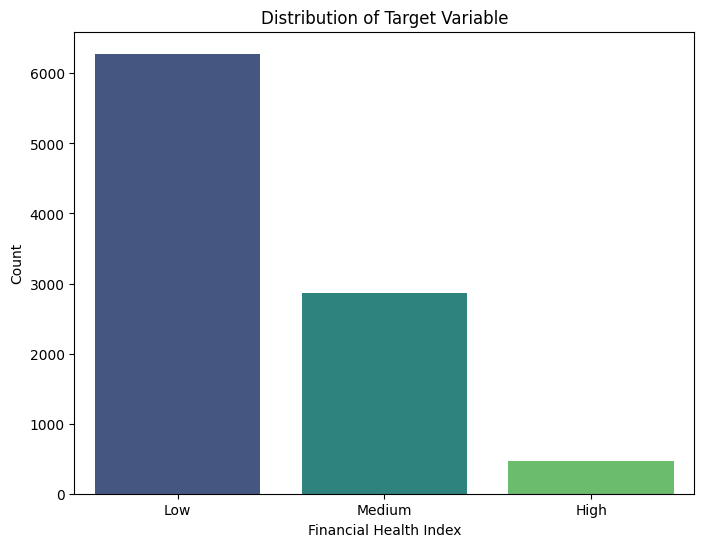

In [88]:
plt.figure(figsize=(8, 6))
sns.countplot(data=train, x='Target', palette='viridis')
plt.title('Distribution of Target Variable')
plt.xlabel('Financial Health Index')
plt.ylabel('Count')
plt.show()

* I see high class imbalance here with Low being the majority and High the minority class

In [89]:
train_df = train
test_df = test

In [90]:
for col in numerical_cols:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)
cols_to_fill_cat = [col for col in categorical_cols if col != 'ID' and col != 'Target']

for col in cols_to_fill_cat:
    train_df[col] = train_df[col].fillna('Missing')
    test_df[col] = test_df[col].fillna('Missing')

# Apply canonization after filling missing values
train_df = canonize_text(train_df, cols_to_fill_cat)
test_df = canonize_text(test_df, cols_to_fill_cat)

* Here I filled missing values with median. Lets see how this performs then we test 0


## Distribution (Normality Check)

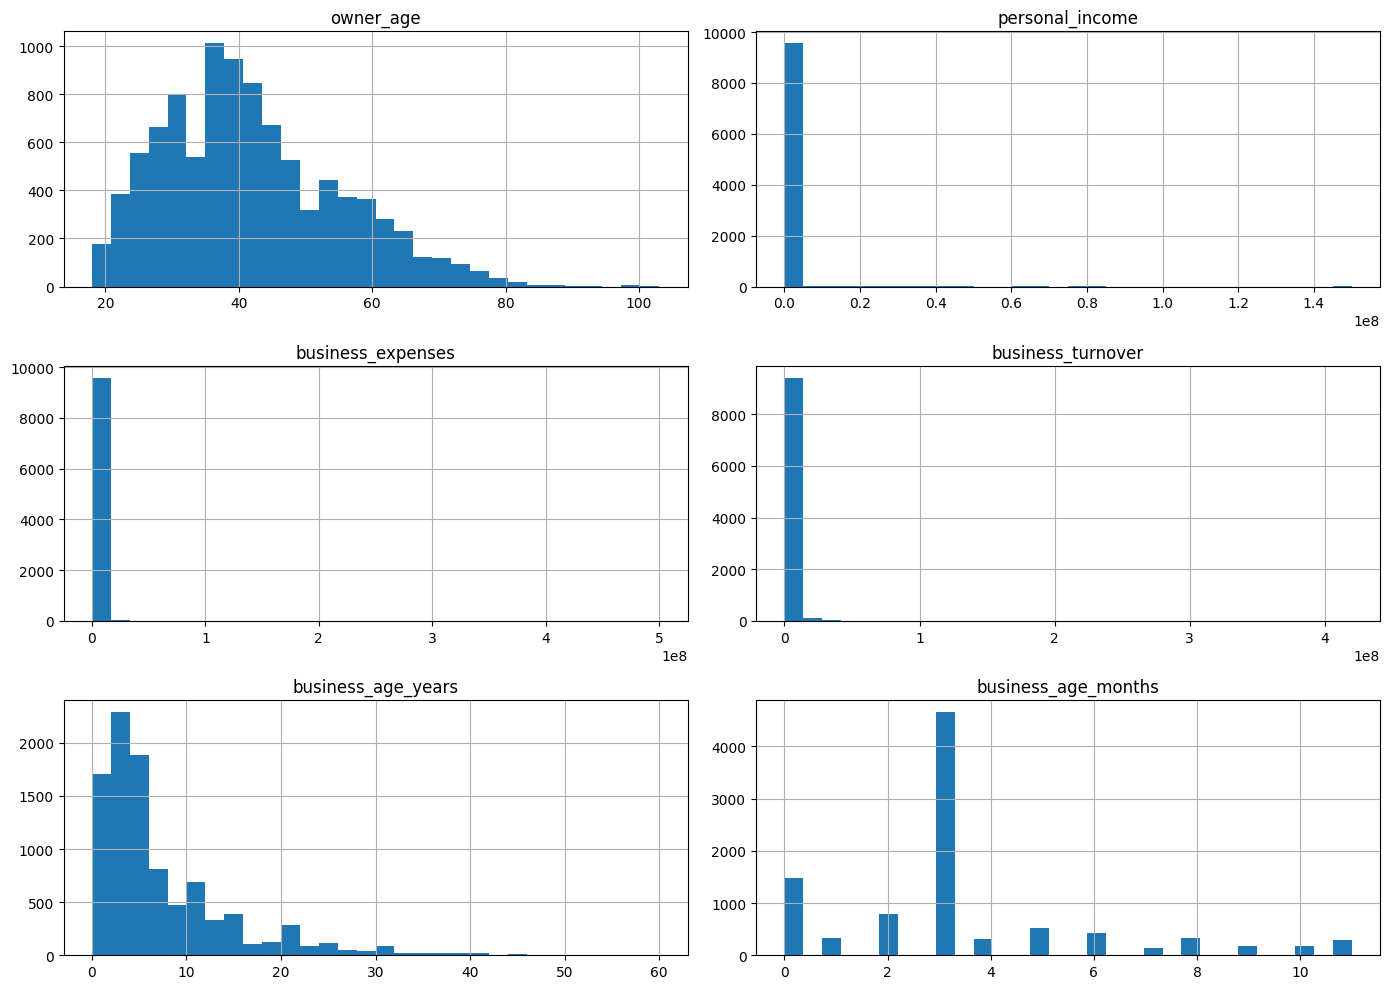

In [91]:
train_df[numerical_cols].hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()

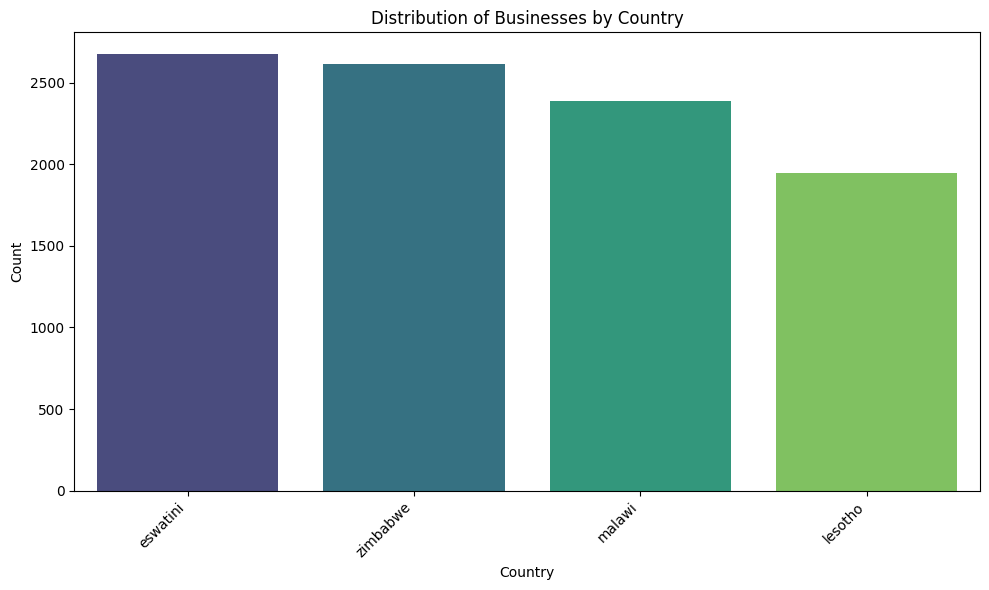

In [92]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='country', hue = 'country', palette='viridis')
plt.title('Distribution of Businesses by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* There is quite a fair distribution of businesses within the 4 countries with Eswatini being the majority and lesotho the minority.

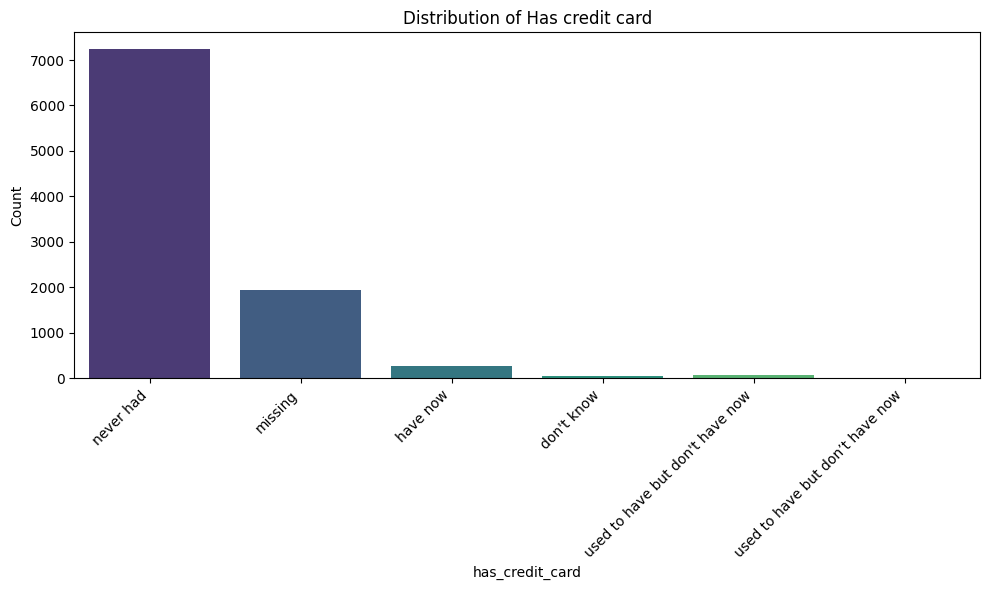

In [93]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='has_credit_card', hue = 'has_credit_card', palette='viridis')
plt.title('Distribution of Has credit card')
plt.xlabel('has_credit_card')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* The majority of the Businesses never had credit card, and the minority class being the businesses who used to have credit card but no longer has it as of the time of the survey.

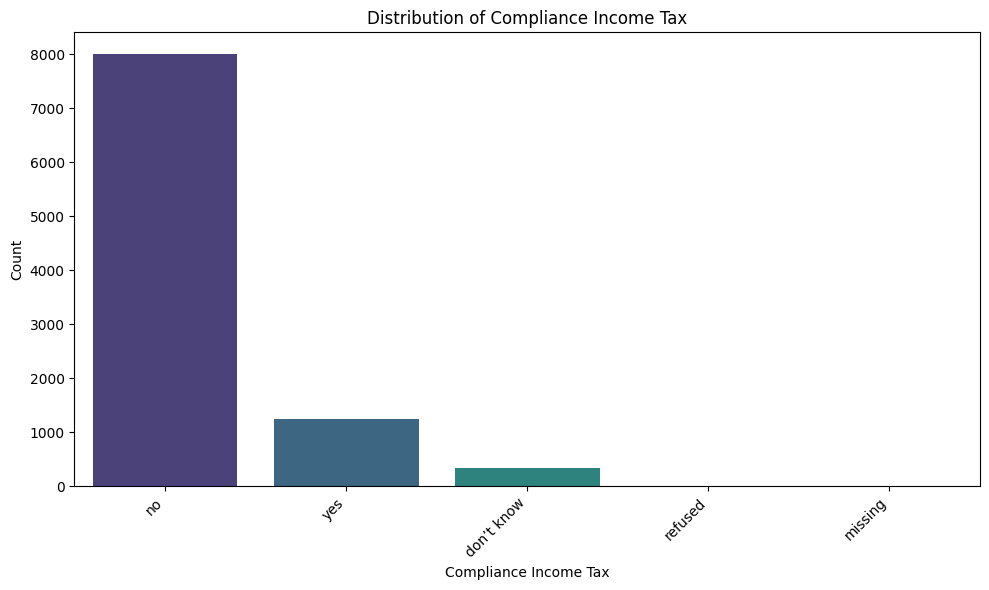

In [94]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='compliance_income_tax', hue = 'compliance_income_tax', palette='viridis')
plt.title('Distribution of Compliance Income Tax')
plt.xlabel('Compliance Income Tax')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* This shows that the majority of the businesses do not comply with income tax, with minority class missing.

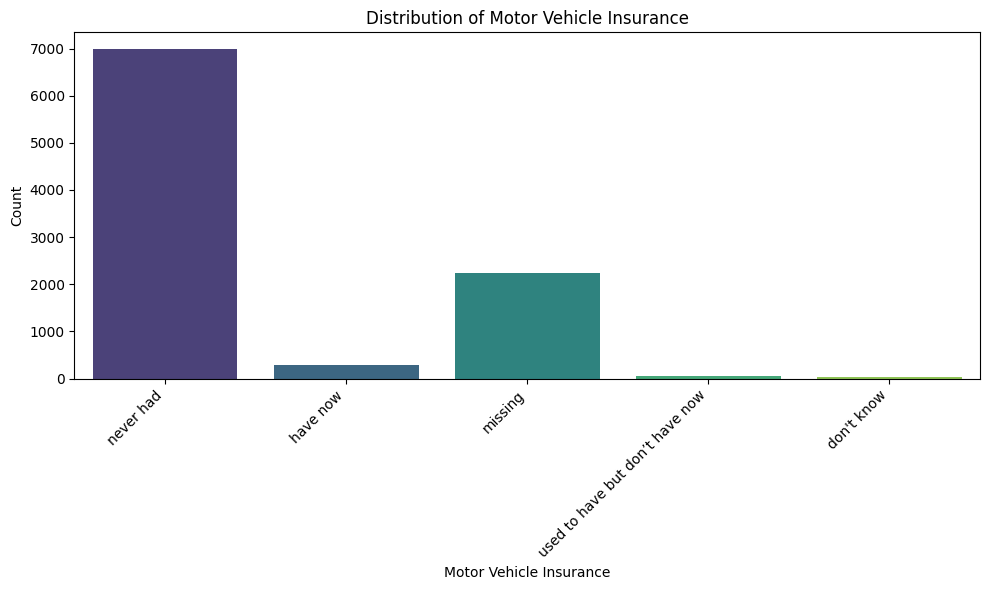

In [95]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='motor_vehicle_insurance', hue = 'motor_vehicle_insurance', palette='viridis')
plt.title('Distribution of Motor Vehicle Insurance')
plt.xlabel('Motor Vehicle Insurance')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This Shows that majority of the businesses never had motor vehicle insurance, little businesses now have the insurance with the minority class being the businesses that do not know if they have the motor vehicle insuarance or not.

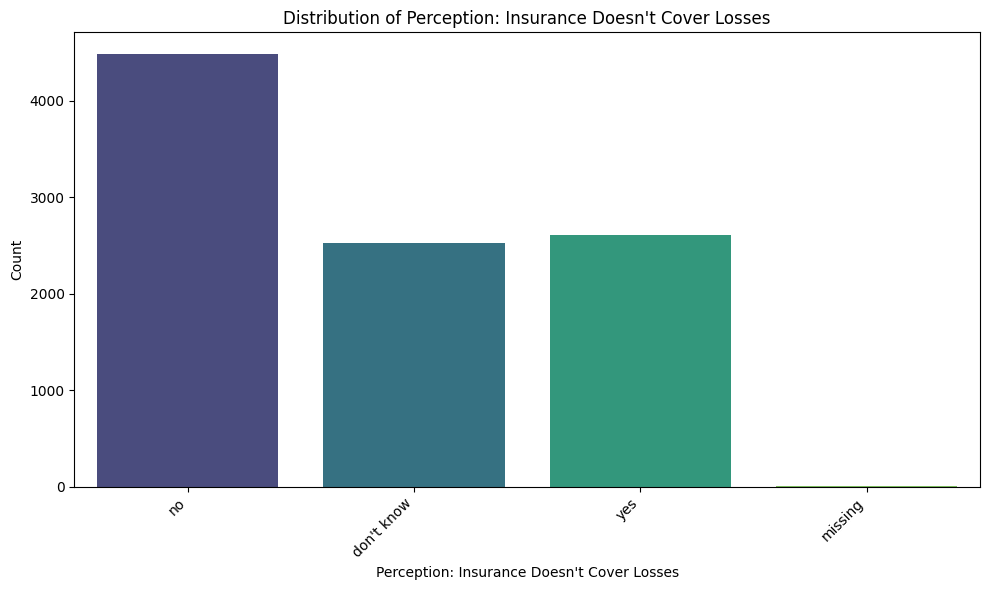

In [96]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='perception_insurance_doesnt_cover_losses', hue='perception_insurance_doesnt_cover_losses', palette='viridis', legend=False)
plt.title('Distribution of Perception: Insurance Doesn\'t Cover Losses')
plt.xlabel('Perception: Insurance Doesn\'t Cover Losses')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

* This shows that the majority of business owners do not have the perception that insurance does not cover losses, with 'Yes' being somewhere at the middle and 'missing' being the minority class.

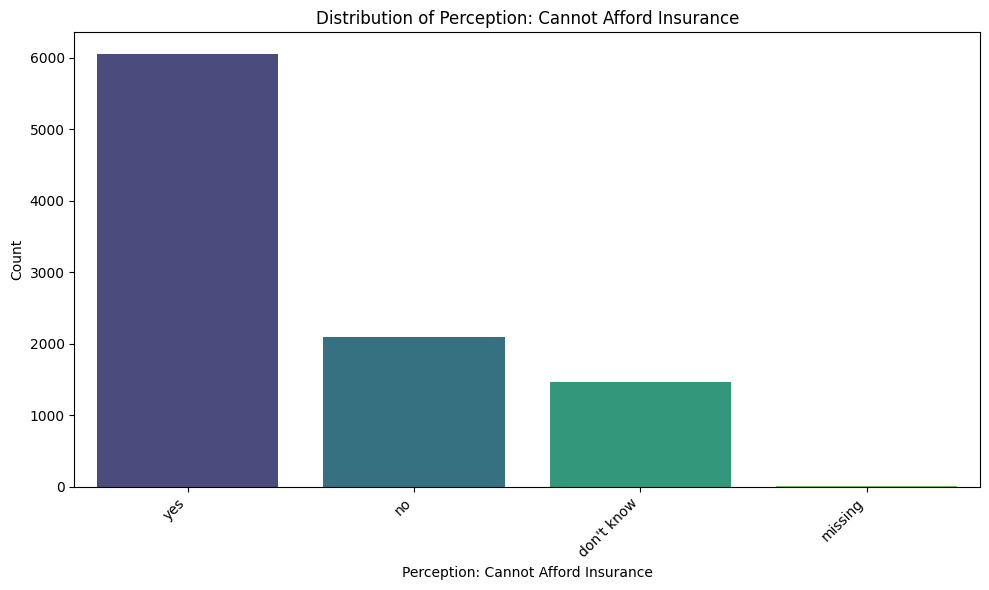

In [97]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='perception_cannot_afford_insurance', hue='perception_cannot_afford_insurance', palette='viridis', legend=False)
plt.title('Distribution of Perception: Cannot Afford Insurance')
plt.xlabel('Perception: Cannot Afford Insurance')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* This shows that majority of the business owners believe that they cannot afford the insurance payments, with the minority at the missing catgory

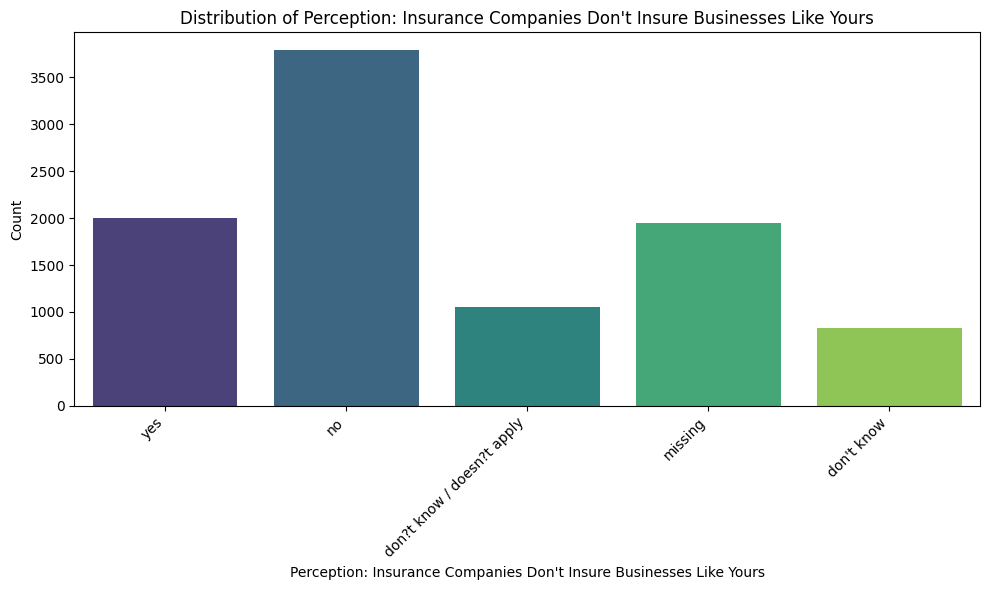

In [98]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='perception_insurance_companies_dont_insure_businesses_like_yours', hue='perception_insurance_companies_dont_insure_businesses_like_yours', palette='viridis', legend=False)
plt.title('Distribution of Perception: Insurance Companies Don\'t Insure Businesses Like Yours')
plt.xlabel('Perception: Insurance Companies Don\'t Insure Businesses Like Yours')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Most business owners believe that insurance companies do not insure businesses like theirs. This perception significantly reduces the likelihood that they will seek insurance coverage, resulting in missed insurance opportunities. A smaller share of respondents reported that they are unsure whether such insurance options exist.

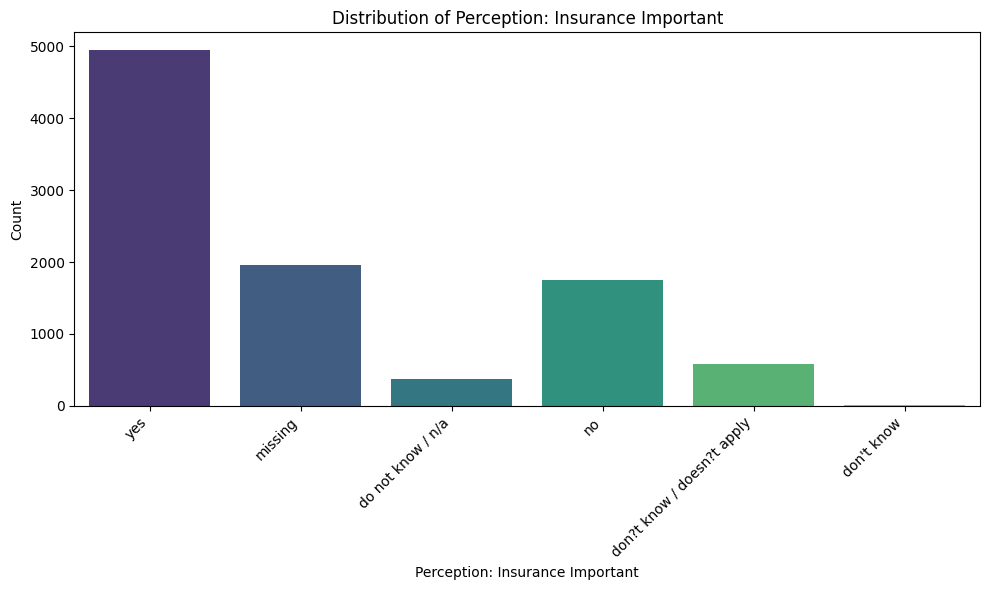

In [99]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='perception_insurance_important', hue='perception_insurance_important', palette='viridis', legend=False)
plt.title('Distribution of Perception: Insurance Important')
plt.xlabel('Perception: Insurance Important')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Most business owners believe that insuring their business is important.

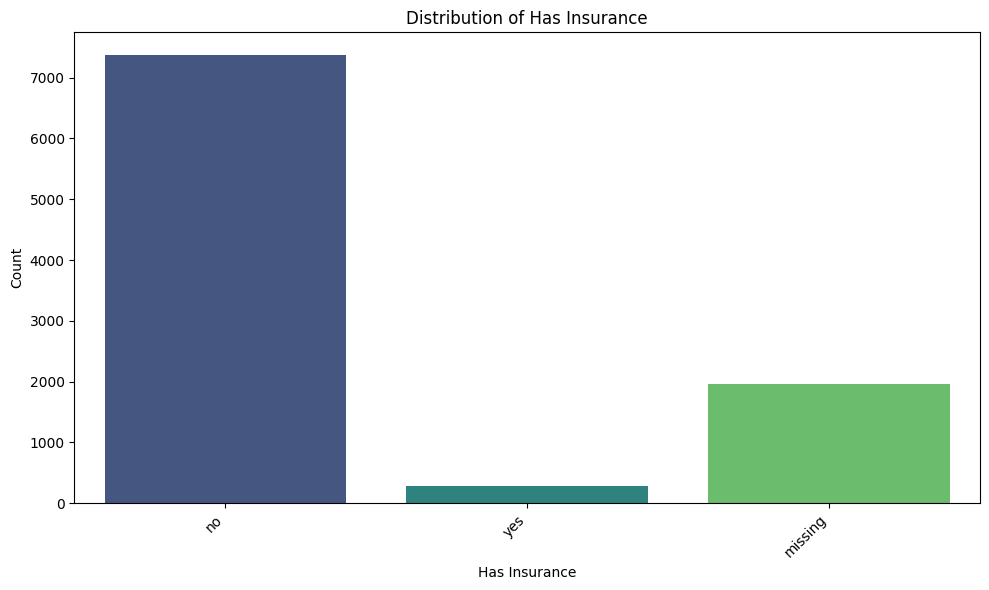

In [100]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='has_insurance', hue='has_insurance', palette='viridis', legend=False)
plt.title('Distribution of Has Insurance')
plt.xlabel('Has Insurance')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* As shown earlier, a large proportion of business owners believe that insurance companies do not insure businesses like theirs. This perception likely contributes to the high number of businesses that remain uninsured. In this case Majority class have not insured their business.

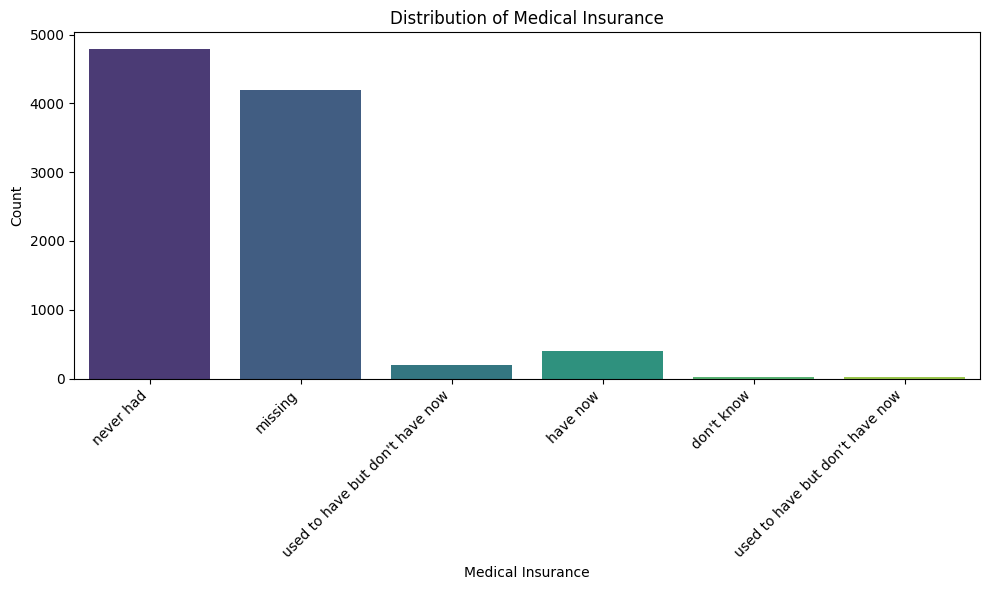

In [101]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='medical_insurance', hue='medical_insurance', palette='viridis', legend=False)
plt.title('Distribution of Medical Insurance')
plt.xlabel('Medical Insurance')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Majority of the farmers never had medical insurance.

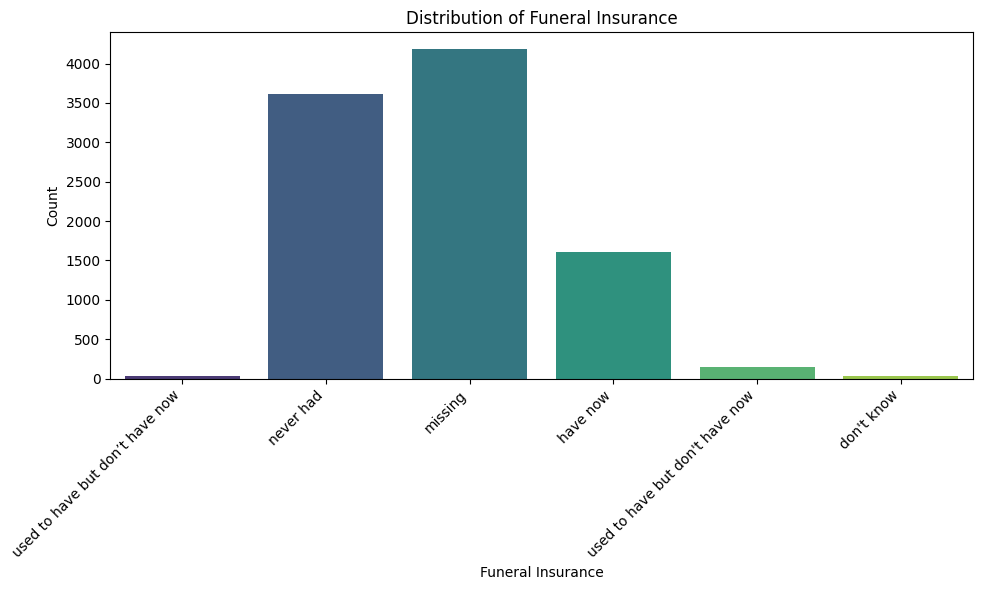

In [102]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='funeral_insurance', hue='funeral_insurance', palette='viridis', legend=False)
plt.title('Distribution of Funeral Insurance')
plt.xlabel('Funeral Insurance')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Majority of the business shows missing Funeral insurance.

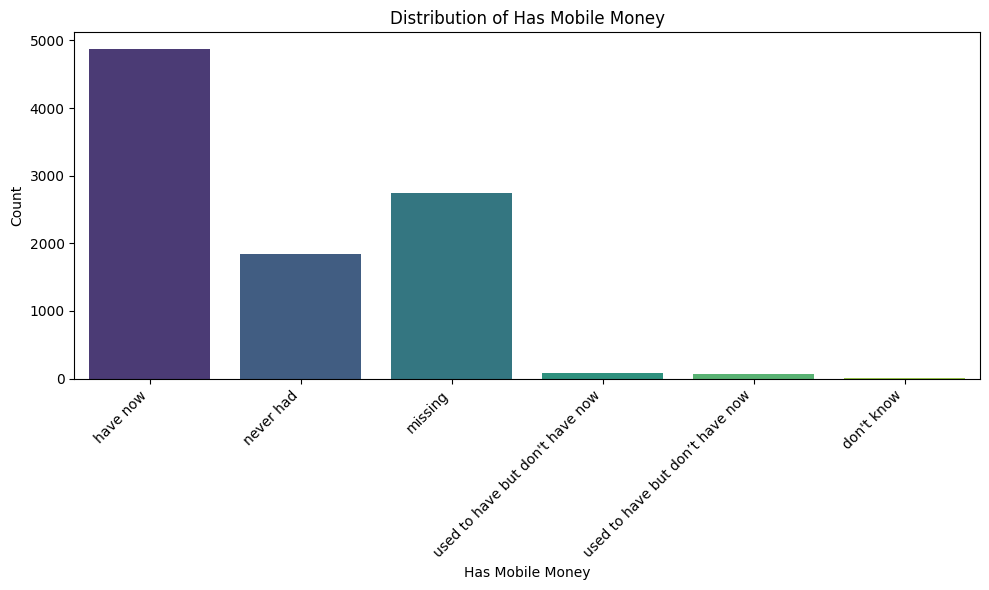

In [103]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='has_mobile_money', hue='has_mobile_money', palette='viridis', legend=False)
plt.title('Distribution of Has Mobile Money')
plt.xlabel('Has Mobile Money')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Majority of the business as of the time of the data collection shows that they now have access to mobile money.


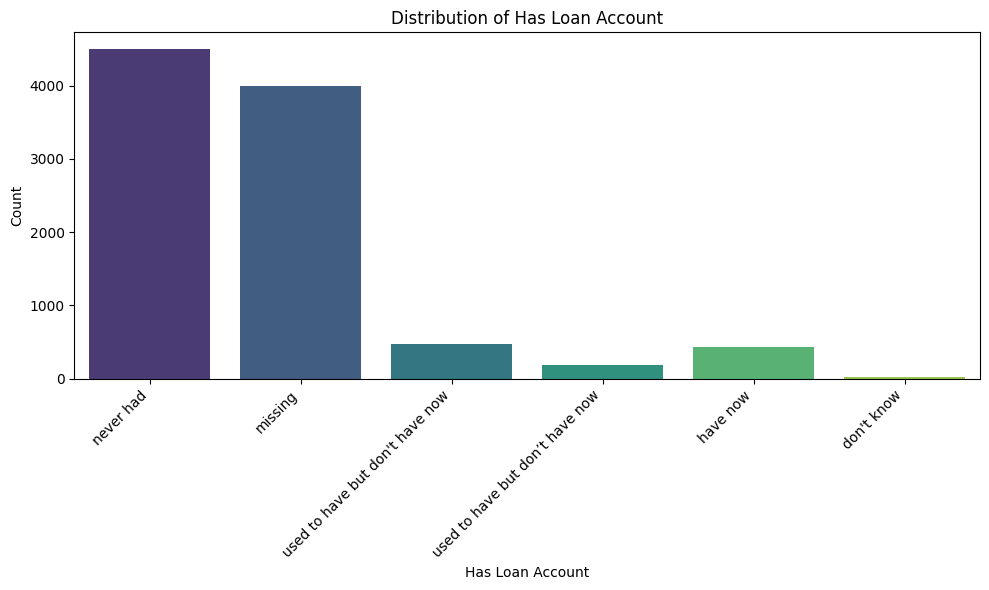

In [104]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='has_loan_account', hue='has_loan_account', palette='viridis', legend=False)
plt.title('Distribution of Has Loan Account')
plt.xlabel('Has Loan Account')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Majority of the business are reported to have never had a load account

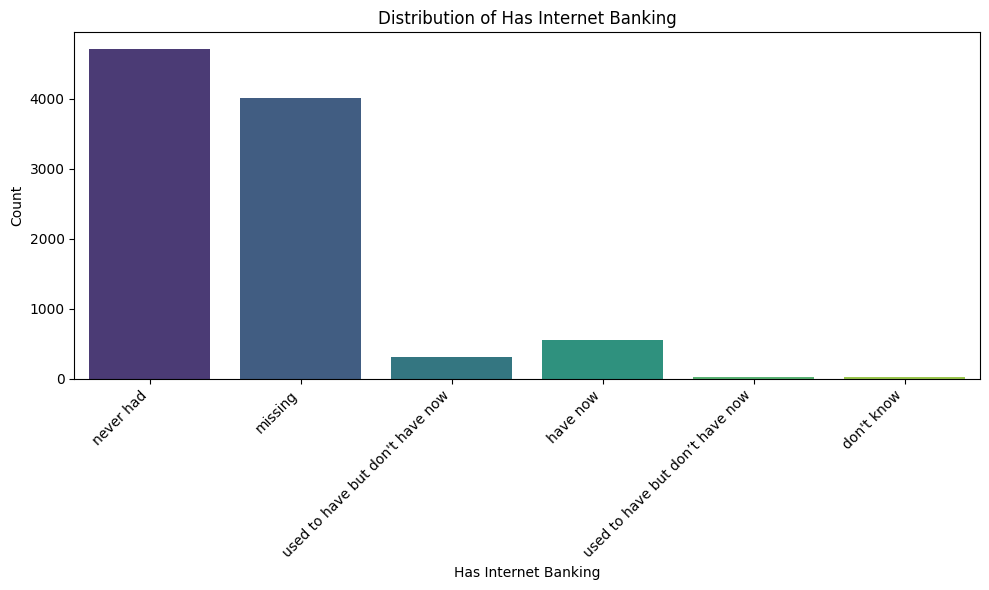

In [105]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='has_internet_banking', hue='has_internet_banking', palette='viridis', legend=False)
plt.title('Distribution of Has Internet Banking')
plt.xlabel('Has Internet Banking')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Majority of the business are shown to never had internet banking.

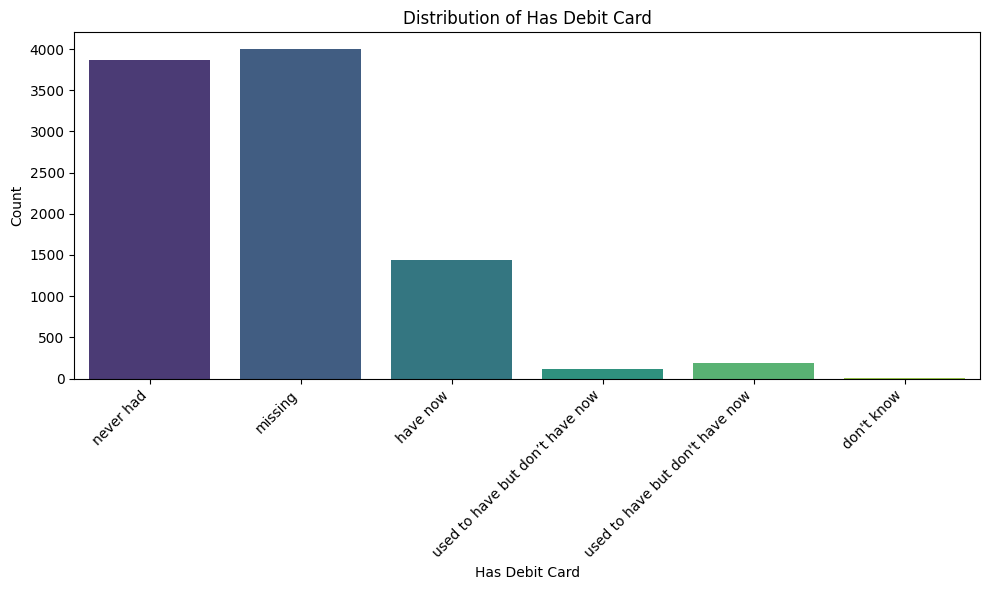

In [106]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='has_debit_card', hue='has_debit_card', palette='viridis', legend=False)
plt.title('Distribution of Has Debit Card')
plt.xlabel('Has Debit Card')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Majority of the business are seen to never had debit card

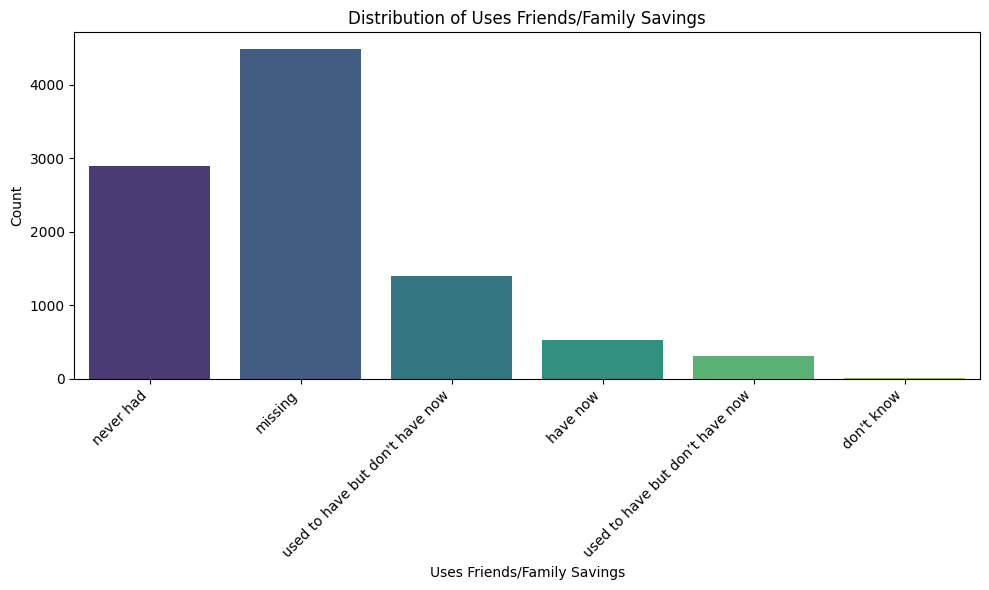

In [107]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='uses_friends_family_savings', hue='uses_friends_family_savings', palette='viridis', legend=False)
plt.title('Distribution of Uses Friends/Family Savings')
plt.xlabel('Uses Friends/Family Savings')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Majority of the business shows that they never used friends/family savings with the minority class do not know/do not show.

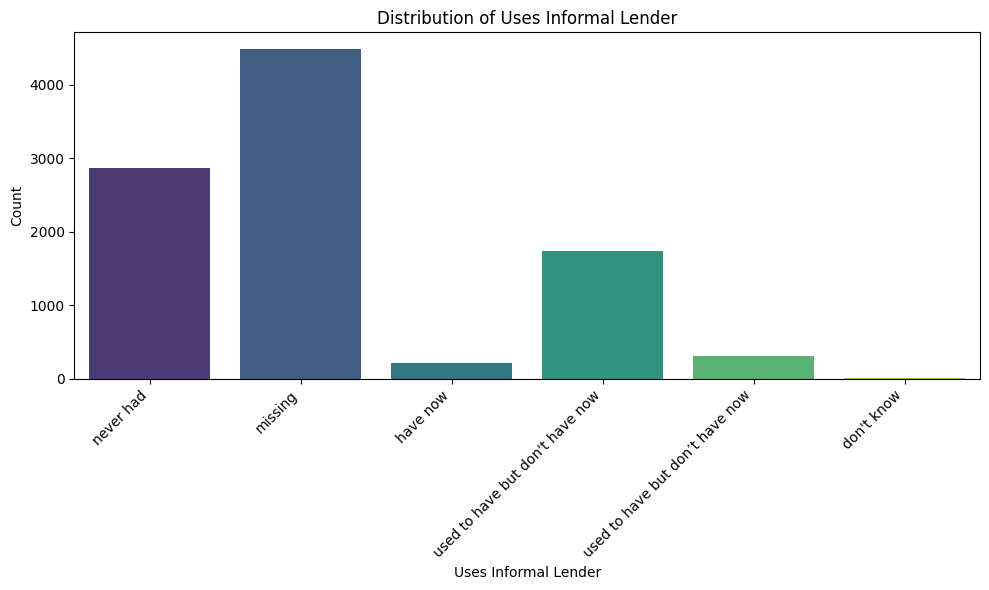

In [108]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='uses_informal_lender', hue='uses_informal_lender', palette='viridis', legend=False)
plt.title('Distribution of Uses Informal Lender')
plt.xlabel('Uses Informal Lender')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* The majority lies under 'Missing' category, followed by 'Never Had' of Informal lender

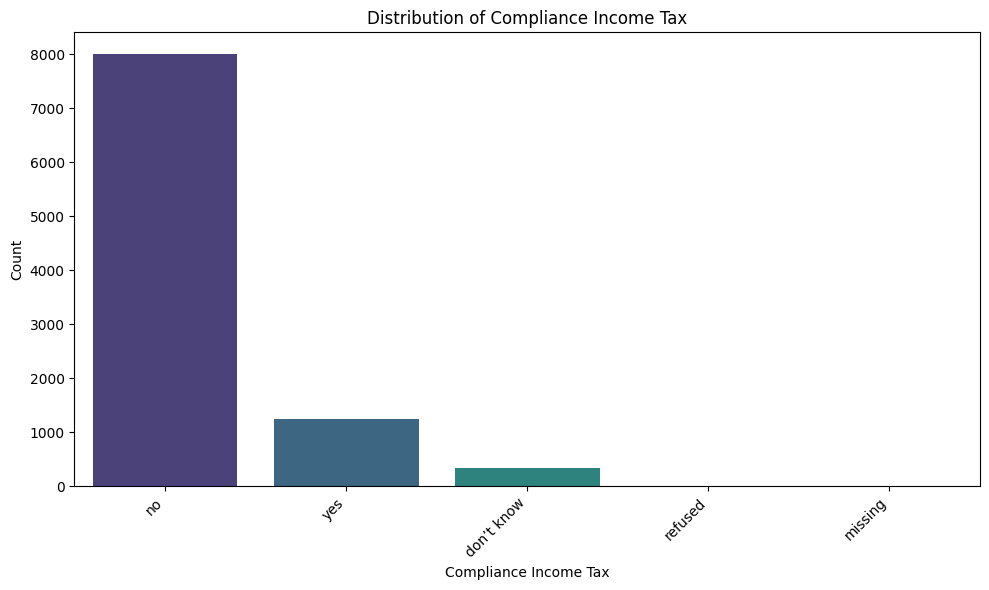

In [109]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='compliance_income_tax', hue='compliance_income_tax', palette='viridis', legend=False)
plt.title('Distribution of Compliance Income Tax')
plt.xlabel('Compliance Income Tax')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*   The majority of businesses indicated 'No' for compliance with income tax, suggesting a high proportion of non-compliance. A significant number of businesses reported 'Yes', indicating compliance.
*   Smaller proportions were observed for 'Don't know' and 'Missing' categories.

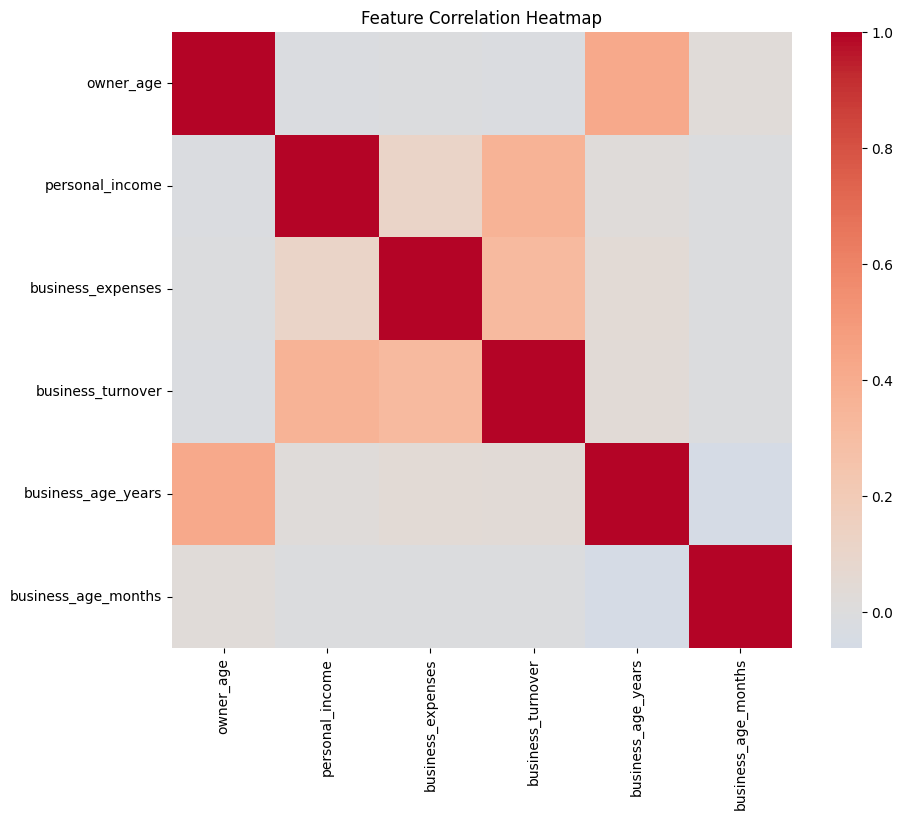

In [110]:
corr = train_df.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


* Top correlation with the target


In [111]:
temp = train_df.copy()

temp["Target_enc"] = temp["Target"].astype("category").cat.codes

# include ALL numeric types
num_df = temp.select_dtypes(include=np.number)

corr_target = (
    num_df.corr()["Target_enc"]
    .drop("Target_enc")
    .sort_values(ascending=False)
)

print(corr_target.head(10))

owner_age              0.049390
business_age_months    0.000707
business_age_years    -0.022270
business_expenses     -0.023443
personal_income       -0.039808
business_turnover     -0.075413
Name: Target_enc, dtype: float64


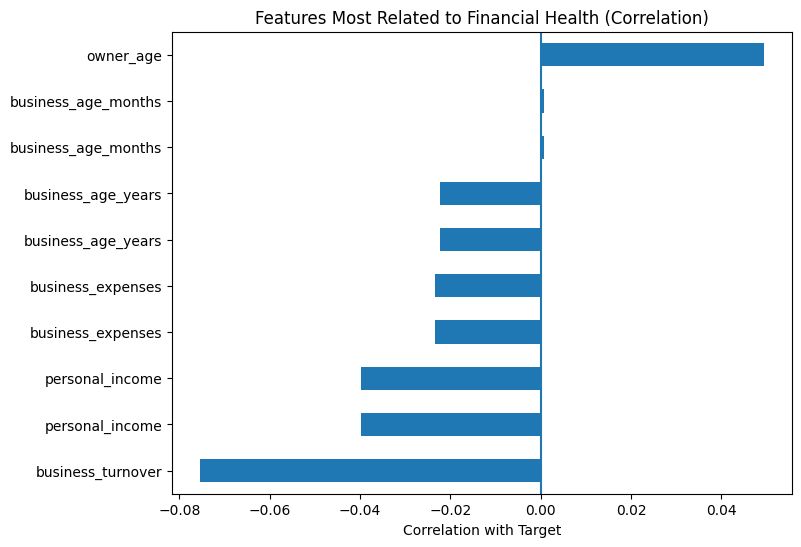

In [112]:
top_features = pd.concat([corr_target.head(5), corr_target.tail(5)])

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind="barh")
plt.axvline(0)
plt.title("Features Most Related to Financial Health (Correlation)")
plt.xlabel("Correlation with Target")
plt.show()


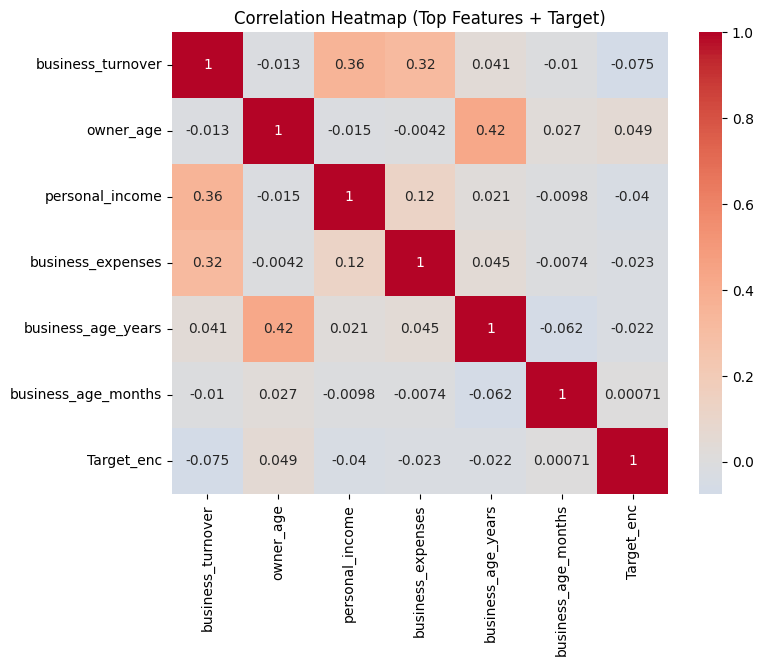

In [113]:
top_cols = corr_target.abs().sort_values(ascending=False).head(10).index.tolist()

plt.figure(figsize=(8,6))
sns.heatmap(num_df[top_cols + ["Target_enc"]].corr(),
            annot=True,
            cmap="coolwarm",
            center=0)

plt.title("Correlation Heatmap (Top Features + Target)")
plt.show()


## Feature Engineering

In [114]:
def create_features(df, country_col='country'):
    """Create comprehensive features for FHI prediction."""
    df = df.copy()

    # Currency normalization
    exchange_rates = {
        'eswatini': 15.2, 'lesotho': 15.2,
        'malawi': 1030.0, 'zimbabwe': 1.0
    }

    country_context = {
        'eswatini': {'gdp_pc': 4000, 'financial_inclusion': 0.65},
        'lesotho': {'gdp_pc': 1200, 'financial_inclusion': 0.51},
        'malawi': {'gdp_pc': 400, 'financial_inclusion': 0.34},
        'zimbabwe': {'gdp_pc': 1800, 'financial_inclusion': 0.55}
    }
    df['country_gdp_per_capita'] = df[country_col].map({k: v['gdp_pc'] for k, v in country_context.items()})

    for col in ['personal_income', 'business_expenses', 'business_turnover']:
        if col in df.columns:
            df[f'{col}_usd'] = df.apply(
                lambda x: x[col] / exchange_rates.get(x[country_col].lower(), 1.0), axis=1
            )

    income_col, expense_col, turnover_col = 'personal_income_usd', 'business_expenses_usd', 'business_turnover_usd'

    # Financial ratios
    df['gross_profit'] = df[turnover_col] - df[expense_col]
    df['profit_margin'] = df['gross_profit'] / (df[turnover_col] + 1)
    df['expense_to_turnover_ratio'] = df[expense_col] / (df[turnover_col] + 1)
    df['cost_burden'] = df[expense_col] / (df[income_col] + df[turnover_col] + 1)

    # Financial access
    digital_services = ['has_mobile_money', 'has_internet_banking', 'has_debit_card']
    df['digital_services_count'] = sum((df[col] == 'have now').astype(int) for col in digital_services if col in df.columns)

    all_services = ['has_mobile_money', 'has_cellphone', 'has_credit_card',
                    'has_internet_banking', 'has_debit_card', 'has_loan_account']
    df['financial_access_score'] = sum((df[col].isin(['yes', 'have now'])).astype(int) for col in all_services if col in df.columns)
    df['financial_access_pct'] = df['financial_access_score'] / len(all_services)

    # Insurance
    insurance_types = ['has_insurance', 'motor_vehicle_insurance', 'medical_insurance', 'funeral_insurance']
    df['insurance_count'] = sum((df[col].isin(['yes', 'have now'])).astype(int) for col in insurance_types if col in df.columns)
    df['has_any_insurance'] = (df['insurance_count'] > 0).astype(int)

    # Business maturity
    df['business_age_total_months'] = df['business_age_years'] * 12 + df['business_age_months']
    df['business_age_years_exact'] = df['business_age_total_months'] / 12
    df['is_startup'] = (df['business_age_years_exact'] <= 2).astype(int)
    df['is_mature'] = (df['business_age_years_exact'] > 10).astype(int)


    # Additional features to try:
    df['log_turnover'] = np.log1p(df[turnover_col])
    df['log_income'] = np.log1p(df[income_col])
    df['turnover_to_income_ratio'] = df[income_col] / (df[turnover_col] + 1) # Changed to income/turnover since turnover/income already exists
    df['business_age_squared'] = df['business_age_years_exact'] ** 2
    df['owner_age_squared'] = df['owner_age'] ** 2

    # Interaction with country context
    df['turnover_per_gdp'] = df[turnover_col] / df['country_gdp_per_capita']
    df['income_per_gdp'] = df[income_col] / df['country_gdp_per_capita']
    df['turnover_vs_gdp'] = df[turnover_col] / df['country_gdp_per_capita'] # Redundant, but kept for consistency

    # Country-relative features
    if country_col in df.columns:
        for col in [turnover_col, 'financial_access_score', 'insurance_count']:
            df[f'{col}_country_rank'] = df.groupby(country_col)[col].rank(pct=True)
            df[f'{col}_vs_country_mean'] = df[col] / (df.groupby(country_col)[col].transform('mean') + 1)


    return df

In [115]:
# Apply feature engineering
train_df = create_features(train_df, country_col='country')
test_df = create_features(test_df, country_col='country')

# Prepare X, y
X = train_df.drop(['ID', 'Target'], axis=1)
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

y = train_df['Target'].map(target_mapping)
y_encoded = y

In [116]:
import lightgbm as lgb

country_selected_features = {}
country_importance_dfs = {}

SEEDS = [1,78,93]

for country in X['country'].unique():

    print(f"\n{'='*60}")
    print(f"Processing country: {country}")
    print(f"{'='*60}")

    country_mask = X['country'] == country

    X_country = X.loc[country_mask].copy()
    y_country = y_encoded.loc[country_mask]

    print(f"Samples: {len(X_country)}")
    print(y_country.value_counts(normalize=True))

    cols_to_drop = ['country']
    X_country_model = X_country.drop(columns=[c for c in cols_to_drop if c in X_country.columns])

    categorical_cols = X_country_model.select_dtypes(include=['object','category']).columns.tolist()

    if categorical_cols:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_country_model[categorical_cols] = encoder.fit_transform(X_country_model[categorical_cols])

    all_seed_importances = []

    for seed in SEEDS:

        skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=seed)

        seed_importances = []

        for fold,(train_idx,val_idx) in enumerate(skf.split(X_country_model,y_country)):

            X_tr = X_country_model.iloc[train_idx]
            X_val = X_country_model.iloc[val_idx]
            y_tr = y_country.iloc[train_idx]
            y_val = y_country.iloc[val_idx]

            # CatBoost
            cat_model = CatBoostClassifier(
                iterations=600,
                depth=6,
                learning_rate=0.1,
                loss_function='MultiClass',
                auto_class_weights='Balanced',
                verbose=False,
                random_seed=seed
            )

            cat_model.fit(X_tr,y_tr,eval_set=(X_val,y_val),verbose=False)

            cat_imp = cat_model.get_feature_importance(type="PredictionValuesChange")

            # LightGBM
            lgb_model = lgb.LGBMClassifier(
                n_estimators=600,
                learning_rate=0.01,
                num_leaves=64,
                class_weight='balanced',
                verbosity=-1,
                random_state=seed
            )

            lgb_model.fit(X_tr,y_tr)

            lgb_imp = lgb_model.feature_importances_

            fold_df = pd.DataFrame({
                "feature":X_country_model.columns,
                "cat_importance":cat_imp,
                "lgb_importance":lgb_imp,
                "seed":seed
            })

            seed_importances.append(fold_df)

        seed_imp_df = pd.concat(seed_importances)

        seed_imp_df = seed_imp_df.groupby("feature")[["cat_importance","lgb_importance"]].mean().reset_index()

        all_seed_importances.append(seed_imp_df)

    imp_df = pd.concat(all_seed_importances)

    imp_df = imp_df.groupby("feature")[["cat_importance","lgb_importance"]].mean().reset_index()

    # Normalize
    imp_df["cat_importance"] /= imp_df["cat_importance"].sum()
    imp_df["lgb_importance"] /= imp_df["lgb_importance"].sum()

    imp_df["importance"] = 0.6*imp_df["cat_importance"] + 0.4*imp_df["lgb_importance"]

    imp_df = imp_df.sort_values("importance",ascending=False)

    imp_df["importance_pct"] = imp_df["importance"]/imp_df["importance"].sum()*100
    imp_df["cumulative_pct"] = imp_df["importance_pct"].cumsum()

    country_importance_dfs[country] = imp_df


    selected_features = imp_df[
        (imp_df["cumulative_pct"]<=90) &
        (imp_df["importance_pct"]>=0.4)
    ]["feature"].tolist()

    if len(selected_features) < 12:
        selected_features = imp_df.head(12)["feature"].tolist()

    if len(selected_features) > 25:
        selected_features = imp_df.head(25)["feature"].tolist()

    country_selected_features[country] = selected_features

    print(f"\nSelected {len(selected_features)} features")
    print(imp_df.head(10)[["feature","importance_pct"]])


Processing country: eswatini
Samples: 2674
Target
0    0.514211
1    0.370980
2    0.114809
Name: proportion, dtype: float64

Selected 25 features
                            feature  importance_pct
38                  insurance_count        7.999859
35                 has_loan_account        7.197261
39     insurance_count_country_rank        5.830178
40  insurance_count_vs_country_mean        5.588255
29                has_any_insurance        4.853425
26                funeral_insurance        4.786794
63         turnover_to_income_ratio        3.541865
51                        owner_age        3.309069
16                      cost_burden        3.184080
31                  has_credit_card        3.182797

Processing country: zimbabwe
Samples: 2612
Target
0    0.685681
1    0.290965
2    0.023354
Name: proportion, dtype: float64

Selected 25 features
                            feature  importance_pct
31                  has_credit_card       10.746609
38                  insuranc

In [117]:
def optimize_thresholds_nelder_mead(y_true, y_proba, country_name):
    """Fast Nelder-Mead optimization for class multipliers."""
    def neg_f1(multipliers):
        multipliers = np.clip(multipliers, 0.5, 5.0)
        adjusted_proba = y_proba * multipliers
        preds = np.argmax(adjusted_proba, axis=1)
        return -f1_score(y_true, preds, average='macro')

    result = minimize(
        neg_f1, np.array([1.0, 1.0, 1.0]), method="Nelder-Mead",
        options={"maxiter": 200, "xatol": 1e-6}
    )

    optimal_multipliers = np.clip(result.x, 0.5, 5.0)
    best_f1 = -result.fun
    default_f1 = f1_score(y_true, np.argmax(y_proba, axis=1), average='macro')

    print(f"  {country_name}: Mult={optimal_multipliers.round(2)}, F1={best_f1:.3f} (gain +{best_f1-default_f1:.3f})")
    return optimal_multipliers, best_f1

In [118]:
def create_optuna_objective(X, y, cat_features, selected_features, country_name):

    global_encoders = {}
    for col in cat_features:
        if col in X.columns:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            global_encoders[col] = le

    def objective(trial):
        cat_params = {
            'iterations': trial.suggest_int('cat_iterations', 300, 700),
            'depth': trial.suggest_int('cat_depth', 4, 8),
            'learning_rate': trial.suggest_float('cat_lr', 0.02, 0.15),
            'l2_leaf_reg': trial.suggest_float('cat_l2', 1, 10),
            'border_count': trial.suggest_int('cat_border_count', 32, 255),
            'random_strength': trial.suggest_float('cat_random_strength', 0.5, 2.0),
            'bagging_temperature': trial.suggest_float('cat_bagging_temp', 0.0, 1.0),
            'rsm': trial.suggest_float('cat_rsm', 0.6, 1.0),
            'grow_policy': trial.suggest_categorical('cat_grow_policy', ['SymmetricTree', 'Depthwise']),
            'loss_function': 'MultiClass',
            'verbose': False
        }

        lgb_params = {
            'n_estimators': trial.suggest_int('lgb_n_estimators', 300, 700),
            'learning_rate': trial.suggest_float('lgb_lr', 0.02, 0.15),
            'num_leaves': trial.suggest_int('lgb_num_leaves', 20, 80),
            'max_depth': trial.suggest_int('lgb_max_depth', 4, 10),
            'min_child_samples': trial.suggest_int('lgb_min_child', 10, 40),
            'subsample': trial.suggest_float('lgb_subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('lgb_colsample', 0.7, 1.0),
            'min_child_samples': trial.suggest_int('lgb_min_child', 10, 60),
            'min_split_gain': trial.suggest_float('lgb_min_split_gain', 0.0, 0.2),
            'subsample': trial.suggest_float('lgb_subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('lgb_colsample', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('lgb_reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('lgb_reg_lambda', 0.0, 5.0),
            'max_bin': trial.suggest_int('lgb_max_bin', 128, 512),
            'objective': 'multiclass',
            'num_class': 3,
            'verbosity': -1
        }


        skf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)
        scores = []

        for seed in [42, 123]:

            fold_scores = []

            for train_idx, val_idx in skf.split(X, y):

                X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]


                cat_cols = X_tr.select_dtypes(include=['object','category']).columns

                X_tr_enc = X_tr.copy()
                X_val_enc = X_val.copy()

                if country_name in ["lesotho","malawi","zimbabwe"]:

                    from imblearn.over_sampling import SMOTE

                    min_class_count = min(np.bincount(y_tr.values))
                    k_neighbors = max(1, min(5, min_class_count - 1))

                    smote = SMOTE(k_neighbors=k_neighbors, random_state=seed)

                    X_res, y_res = smote.fit_resample(X_tr_enc, y_tr)


                    X_tr_final = pd.DataFrame(X_res, columns=X_tr_enc.columns)
                    y_tr_final = pd.Series(y_res)

                else:
                    X_tr_final = X_tr_enc
                    y_tr_final = y_tr

                cat_model = CatBoostClassifier(**cat_params, random_seed=seed)
                cat_model.fit(X_tr_final, y_tr_final, verbose=False)

                lgb_model = lgb.LGBMClassifier(**lgb_params, random_state=seed)
                lgb_model.fit(
                    X_tr_final, y_tr_final,
                    eval_set=[(X_val_enc, y_val)],
                    callbacks=[lgb.early_stopping(100, verbose=False)]
                )
                cat_probs = cat_model.predict_proba(X_val_enc)
                lgb_probs = lgb_model.predict_proba(X_val_enc)

                preds = np.argmax(0.6 * cat_probs + 0.4 * lgb_probs, axis=1)

                fold_scores.append(f1_score(y_val, preds, average='macro'))

            scores.append(np.mean(fold_scores))

        return np.mean(scores)

    return objective

In [119]:
country_final_models = {}
country_best_multipliers = {}
country_best_params = {}

# Populate country_best_params using Optuna
for country in X['country'].unique():
    print(f"\n{'='*60}")
    print(f"Optimizing hyperparameters for {country} with Optuna")
    print(f"{'='*60}")

    mask = X['country'] == country
    X_country_optuna = X.loc[mask][country_selected_features[country]].copy()
    y_country_optuna = y_encoded.loc[mask]

    # Convert categorical features to category dtype for LightGBM
    for col in X_country_optuna.select_dtypes(include=['object']).columns:
        X_country_optuna[col] = X_country_optuna[col].astype('category')

    objective = create_optuna_objective(X_country_optuna, y_country_optuna, X_country_optuna.select_dtypes(include=['category']).columns.tolist(), country_selected_features[country], country)

    study = optuna.create_study(direction='maximize', study_name=f"fhi_model_{country}")
    study.optimize(objective, n_trials=10, show_progress_bar=True) # Reduced trials for faster execution

    country_best_params[country] = study.best_params
    print(f"Best F1 for {country}: {study.best_value:.4f}")
    print(f"Best parameters for {country}: {study.best_params}")


country_oof_predictions = np.zeros((len(X), 3))
country_oof_classes = np.zeros(len(X), dtype=int)

for country in X['country'].unique():

    print(f"\n{'='*60}")
    print(f"Final Training for {country}")
    print(f"{'='*60}")

    mask = X['country'] == country
    idx = X.loc[mask].index

    X_country = X.loc[mask][country_selected_features[country]].copy()
    y_country = y_encoded.loc[mask]

    SEEDS = [42, 78]
    all_preds = []

    for seed in SEEDS:

        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
        oof = np.zeros((len(X_country), 3))

        for train_idx, val_idx in skf.split(X_country, y_country):

            X_tr, X_val = X_country.iloc[train_idx], X_country.iloc[val_idx]
            y_tr, y_val = y_country.iloc[train_idx], y_country.iloc[val_idx]

            # Encode once
            cat_cols = X_tr.select_dtypes(include=['object','category']).columns

            X_tr_enc = X_tr.copy()
            X_val_enc = X_val.copy()

            # Use the global_encoders here, fit on X_country_optuna (which is X for the current country)
            global_encoders_for_loop = {}

            # It should refer to the categorical columns of X_country
            current_cat_features = X_country.select_dtypes(include=['object','category']).columns.tolist()
            for col in current_cat_features:
                if col in X_country.columns:
                    le = LabelEncoder()
                    le.fit(X_country[col].astype(str))
                    global_encoders_for_loop[col] = le

            for col in current_cat_features:
                if col in X_tr_enc.columns:
                    X_tr_enc[col] = global_encoders_for_loop[col].transform(X_tr[col].astype(str))
                    X_val_enc[col] = global_encoders_for_loop[col].transform(X_val[col].astype(str))

            # SMOTE FIX
            if country in ["lesotho","malawi","zimbabwe"]:

                from imblearn.over_sampling import SMOTE

                min_class = min(np.bincount(y_tr.values))
                k = max(1, min(5, min_class - 1))

                smote = SMOTE(k_neighbors=k, random_state=seed)

                X_res, y_res = smote.fit_resample(X_tr_enc, y_tr)

                X_tr_final = pd.DataFrame(X_res, columns=X_tr_enc.columns)
                y_tr_final = pd.Series(y_res)

            else:
                X_tr_final = X_tr_enc
                y_tr_final = y_tr

            # Models with best params
            best = country_best_params[country]

            # Split best parameters for CatBoost and LightGBM
            cat_best_params = {}
            for k, v in best.items():
                if k.startswith('cat_'):
                    param_name = k.replace('cat_', '')
                    if param_name == 'lr':
                        cat_best_params['learning_rate'] = v
                    elif param_name == 'l2':
                        cat_best_params['l2_leaf_reg'] = v
                    elif param_name == 'bagging_temp':
                        cat_best_params['bagging_temperature'] = v
                    else:
                        cat_best_params[param_name] = v

            lgb_best_params = {
                k.replace('lgb_', ''): v for k, v in best.items() if k.startswith('lgb_')
            }

            cat_model = CatBoostClassifier(**cat_best_params, random_seed=seed, loss_function='MultiClass', verbose=False)
            cat_model.fit(X_tr_final, y_tr_final, verbose=False)

            lgb_model = lgb.LGBMClassifier(**lgb_best_params, random_state=seed, objective='multiclass', num_class=3, verbosity=-1)
            lgb_model.fit(
                X_tr_final, y_tr_final,
                eval_set=[(X_val_enc, y_val)],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )

            probs = 0.6 * cat_model.predict_proba(X_val_enc) + \
                    0.4 * lgb_model.predict_proba(X_val_enc)

            oof[val_idx] = probs

        all_preds.append(oof)

    mean_preds = np.mean(all_preds, axis=0)

    # Optimize thresholds for current country
    current_country_y_true = y_country.values
    current_country_y_proba = mean_preds
    optimal_multipliers, _ = optimize_thresholds_nelder_mead(
        current_country_y_true, current_country_y_proba, country
    )
    country_best_multipliers[country] = optimal_multipliers

    # Apply optimized multipliers to OOF predictions
    adjusted_oof_preds = current_country_y_proba * np.array(optimal_multipliers)
    preds = np.argmax(adjusted_oof_preds, axis=1)

    country_oof_predictions[idx] = mean_preds
    country_oof_classes[idx] = preds

    print("F1 (after threshold optimization):", f1_score(y_country, preds, average='macro'))



SEEDS_FINAL = [42, 78, 123]

country_final_models = {}
for country in X['country'].unique():
    print(f"\n{'='*60}")
    print(f"Training final models for {country} on full data")
    print(f"{'='*60}")

    mask = X['country'] == country
    X_country_full = X.loc[mask][country_selected_features[country]].copy()
    y_country_full = y_encoded.loc[mask]

    # Encode categorical features for the full dataset
    cat_cols_full = X_country_full.select_dtypes(include=['object','category']).columns

    # Global encoders for final model training on full data
    global_encoders_full_data = {}
    # Get the relevant slice of test_df for the current country
    full_test_df_for_country = test_df.loc[test_df['country'] == country].copy()

    for col in cat_cols_full:
        if col in X_country_full.columns:
            le = LabelEncoder()
            train_cats = X_country_full[col].astype(str).unique()
            test_cats = full_test_df_for_country[col].astype(str).unique()
            all_cats = np.unique(np.concatenate((train_cats, test_cats)))
            le.fit(all_cats)
            global_encoders_full_data[col] = le

    X_country_full_encoded = X_country_full.copy()
    for col in cat_cols_full:
        if col in X_country_full_encoded.columns:
            X_country_full_encoded[col] = global_encoders_full_data[col].transform(X_country_full_encoded[col].astype(str))


    # SMOTE FIX
    if country in ["lesotho","malawi","zimbabwe"]:
        min_class = min(np.bincount(y_country_full.values))
        k = max(1, min(5, min_class - 1))
        smote = SMOTE(k_neighbors=k, random_state=42)
        X_country_full_res, y_country_full_res = smote.fit_resample(X_country_full_encoded, y_country_full)
    else:
        X_country_full_res, y_country_full_res = X_country_full_encoded, y_country_full

    final_cat_models = []
    final_lgb_models = []

    for seed in SEEDS_FINAL:
        cat_best_params_final = {}
        for k, v in best.items():
            if k.startswith('cat_'):
                param_name = k.replace('cat_', '')
                if param_name == 'lr':
                    cat_best_params_final['learning_rate'] = v
                elif param_name == 'l2':
                    cat_best_params_final['l2_leaf_reg'] = v
                elif param_name == 'bagging_temp':
                    cat_best_params_final['bagging_temperature'] = v
                else:
                    cat_best_params_final[param_name] = v

        cat_model = CatBoostClassifier(**cat_best_params_final, random_seed=seed, loss_function='MultiClass', verbose=False)
        cat_model.fit(X_country_full_res, y_country_full_res, verbose=False)
        final_cat_models.append(cat_model)

        lgb_model = lgb.LGBMClassifier(**lgb_best_params, random_state=seed, objective='multiclass', num_class=3, verbosity=-1)
        lgb_model.fit(X_country_full_res, y_country_full_res)
        final_lgb_models.append(lgb_model)

    country_final_models[country] = {
        'cat_models': final_cat_models,
        'lgb_models': final_lgb_models,
        'feature_cols': country_selected_features[country],
        'global_encoders_full_data': global_encoders_full_data
    }

[I 2026-03-17 12:33:56,919] A new study created in memory with name: fhi_model_eswatini



Optimizing hyperparameters for eswatini with Optuna


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-17 12:36:33,221] Trial 0 finished with value: 0.8387368210800427 and parameters: {'cat_iterations': 437, 'cat_depth': 8, 'cat_lr': 0.09592095769685073, 'cat_l2': 4.700394118568012, 'cat_border_count': 67, 'cat_random_strength': 1.3535678024787186, 'cat_bagging_temp': 0.9636708814331352, 'cat_rsm': 0.619546995406723, 'cat_grow_policy': 'SymmetricTree', 'lgb_n_estimators': 679, 'lgb_lr': 0.025516522470040725, 'lgb_num_leaves': 78, 'lgb_max_depth': 9, 'lgb_min_child': 31, 'lgb_subsample': 0.7158899650956161, 'lgb_colsample': 0.7494663529541598, 'lgb_min_split_gain': 0.09705857437859983, 'lgb_reg_alpha': 1.055349852161741, 'lgb_reg_lambda': 2.1749973660261155, 'lgb_max_bin': 410}. Best is trial 0 with value: 0.8387368210800427.
[I 2026-03-17 12:38:25,761] Trial 1 finished with value: 0.8361387303371732 and parameters: {'cat_iterations': 446, 'cat_depth': 4, 'cat_lr': 0.11727266072170707, 'cat_l2': 1.796250587457753, 'cat_border_count': 63, 'cat_random_strength': 0.94781608193119

[I 2026-03-17 13:04:22,503] A new study created in memory with name: fhi_model_zimbabwe


...

[I 2026-03-17 13:56:18,187] Trial 0 finished with value: 0.732468098222479 and parameters: {'cat_iterations': 617, 'cat_depth': 6, 'cat_lr': 0.12053465529354765, 'cat_l2': 2.5682767956720682, 'cat_border_count': 39, 'cat_random_strength': 1.988973168453, 'cat_bagging_temp': 0.040735061494131974, 'cat_rsm': 0.8930180942233963, 'cat_grow_policy': 'Depthwise', 'lgb_n_estimators': 431, 'lgb_lr': 0.14768268624455863, 'lgb_num_leaves': 31, 'lgb_max_depth': 7, 'lgb_min_child': 36, 'lgb_subsample': 0.9529451723052658, 'lgb_colsample': 0.8234065864478567, 'lgb_min_split_gain': 0.11151436188784221, 'lgb_reg_alpha': 3.2294723069568128, 'lgb_reg_lambda': 4.44568346589513, 'lgb_max_bin': 455}. Best is trial 0 with value: 0.732468098222479.
[I 2026-03-17 14:02:07,926] Trial 1 finished with value: 0.7255236665110932 and parameters: {'cat_iterations': 529, 'cat_depth': 8, 'cat_lr': 0.09843600304642598, 'cat_l2': 2.187049106610132, 'cat_border_count': 100, 'cat_random_strength': 0.8022554191515225, 'ca

[I 2026-03-17 14:25:19,347] A new study created in memory with name: fhi_model_lesotho


[I 2026-03-17 14:25:19,309] Trial 9 finished with value: 0.7290973721784009 and parameters: {'cat_iterations': 642, 'cat_depth': 5, 'cat_lr': 0.06724267245781772, 'cat_l2': 8.152537947466744, 'cat_border_count': 39, 'cat_random_strength': 1.31531153477429, 'cat_bagging_temp': 0.8639611535004569, 'cat_rsm': 0.6224480894712359, 'cat_grow_policy': 'SymmetricTree', 'lgb_n_estimators': 346, 'lgb_lr': 0.03728421880793149, 'lgb_num_leaves': 71, 'lgb_max_depth': 6, 'lgb_min_child': 13, 'lgb_subsample': 0.9128412966389392, 'lgb_colsample': 0.8516259856002617, 'lgb_min_split_gain': 0.08692799535436085, 'lgb_reg_alpha': 1.5722490618990297, 'lgb_reg_lambda': 4.4915290736408675, 'lgb_max_bin': 237}. Best is trial 2 with value: 0.7413544619942969.
Best F1 for malawi: 0.7414
Best parameters for malawi: {'cat_iterations': 622, 'cat_depth': 4, 'cat_lr': 0.10547833200817273, 'cat_l2': 5.973960547874171, 'cat_border_count': 185, 'cat_random_strength': 1.4664920596834579, 'cat_bagging_temp': 0.48783939870

  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-17 14:31:18,757] Trial 0 finished with value: 0.5601612038138242 and parameters: {'cat_iterations': 558, 'cat_depth': 8, 'cat_lr': 0.11370132897367378, 'cat_l2': 6.5970590092612476, 'cat_border_count': 38, 'cat_random_strength': 0.7317904598257521, 'cat_bagging_temp': 0.15441924875890478, 'cat_rsm': 0.6287416581689008, 'cat_grow_policy': 'Depthwise', 'lgb_n_estimators': 320, 'lgb_lr': 0.04436144298294492, 'lgb_num_leaves': 31, 'lgb_max_depth': 10, 'lgb_min_child': 18, 'lgb_subsample': 0.9419363413549341, 'lgb_colsample': 0.9842186495337621, 'lgb_min_split_gain': 0.14350000467121524, 'lgb_reg_alpha': 2.845247600120167, 'lgb_reg_lambda': 3.273505416151771, 'lgb_max_bin': 159}. Best is trial 0 with value: 0.5601612038138242.
[I 2026-03-17 14:33:33,188] Trial 1 finished with value: 0.5648194904950763 and parameters: {'cat_iterations': 319, 'cat_depth': 7, 'cat_lr': 0.13110387075660346, 'cat_l2': 5.797284932140726, 'cat_border_count': 107, 'cat_random_strength': 1.856854345549605

In [127]:
test_df_prediction = test_df.copy()
submission_df = sample_sub.copy()

# Reverse mapping for labels
reverse_target_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}

# Initialize an empty array for all test predictions to store single class labels
all_test_preds = np.zeros(len(test_df_prediction), dtype=int)
test_ids = test_df_prediction['ID'].values

for country in test_df_prediction['country'].unique():
    print(f"\nProcessing test predictions for country: {country}")

    # Filter test data for the current country
    country_mask = test_df_prediction['country'] == country
    X_test_country_filtered = test_df_prediction.loc[country_mask].copy()
    country_test_ids = X_test_country_filtered['ID'].values

    # Select features based on what was chosen during training for this country
    feature_cols = country_final_models[country]['feature_cols']
    X_test_selected = X_test_country_filtered[feature_cols].copy()

    # Get the encoders trained on full training data for this country
    global_encoders_full_data = country_final_models[country]['global_encoders_full_data']

    # Encode categorical features in the test data using the global encoders
    cat_cols_to_encode = X_test_selected.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols_to_encode:
        if col in global_encoders_full_data:
            X_test_selected[col] = global_encoders_full_data[col].transform(X_test_selected[col].astype(str))
        else:
            # Handle cases where a category might exist in test but not in train,
            # or if for some reason the encoder wasn't fitted for it (shouldn't happen with global_encoders_full_data)
            print(f"Warning: Encoder for column '{col}' not found for country '{country}'. Filling with -1.")
            le = LabelEncoder()
            # Fit on available test data categories to prevent errors, and transform
            le.fit(X_test_selected[col].astype(str).unique())
            X_test_selected[col] = le.transform(X_test_selected[col].astype(str))

    country_seed_predictions = []

    # Make predictions with each model from each seed
    for i in range(len(country_final_models[country]['cat_models'])):
        cat_model = country_final_models[country]['cat_models'][i]
        lgb_model = country_final_models[country]['lgb_models'][i]

        cat_proba = cat_model.predict_proba(X_test_selected)
        lgb_proba = lgb_model.predict_proba(X_test_selected)

        # Average ensemble predictions
        ensemble_proba = 0.6 * cat_proba + 0.4 * lgb_proba
        country_seed_predictions.append(ensemble_proba)

    # Average predictions across seeds
    country_avg_proba = np.mean(country_seed_predictions, axis=0)


    multipliers = country_best_multipliers[country]

    adjusted_proba = country_avg_proba * np.array(multipliers)
    country_test_classes = np.argmax(adjusted_proba, axis=1)

    original_indices = test_df_prediction[test_df_prediction['ID'].isin(country_test_ids)].index
    all_test_preds[original_indices] = country_test_classes # Assign directly without newaxis



final_labels = [reverse_target_mapping[pred] for pred in all_test_preds]

# Populate the submission DataFrame
submission_df['Target'] = final_labels

# Save the submission file
submission_file_path = "submission_go.csv"
submission_df.to_csv(submission_file_path, index=False)

print(f"\nSubmission file '{submission_file_path}' created successfully!")



Processing test predictions for country: zimbabwe

Processing test predictions for country: lesotho

Processing test predictions for country: malawi

Processing test predictions for country: eswatini

Submission file 'submission_go.csv' created successfully!
First 5 rows of the submission file:
          ID  Target
0  ID_5EGLKX     Low
1  ID_4AI7RE  Medium
2  ID_V9OB3M     Low
3  ID_6OI9DI     Low
4  ID_H2TN8B     Low
